# 因子核对 — 研究环境 vs 实时测试环境

> 参考 `check_factor.ipynb` 展示风格，适配 `strategy_PAMY_dev` 实时数据路径。

In [1]:
# ==================== 配置区 ====================
symbol = "C"                       # 品种: P, A, M, Y, C, CS, B, LH
contract = f"{symbol.lower()}2605"         # 合约代码

In [2]:
import matplotlib.pyplot as plt

# 自动读取 replay_mode 配置（dev 环境）
# 如果 replay_mode.enabled=true，save_files 中的 datetime 已替换为指定日期
# 如果 replay_mode.enabled=false，保留手动指定日期
import json as _json
_config_path = "/home/strategy_PAMY_dev/config.json"
_replay_mode = _json.load(open(_config_path)).get('replay_mode', {})
if _replay_mode.get('enabled'):
    night_date = _replay_mode.get('night_date', '2026-03-22')
    day_date = _replay_mode.get('day_date', '2026-03-23')
    print(f"[Replay] 自动读取 config: night={night_date}, day={day_date}")
else:
    # 手动指定（replay_mode 未启用时）
    night_date = "2026-03-23"
    day_date = "2026-03-24"
    print(f"[Manual] 手动指定: night={night_date}, day={day_date}")

# backtest_v3 模型配置（用于生成研究环境预测值）
train_end_date = '2025-01-01'
folder_name = f'{symbol}_pred5_{train_end_date}_v0'

# 路径
rt_prefix = "/home/strategy_PAMY_dev/save_files"
research_prefix = "/mnt/Data/writable/liaoyuyang/factor"
MODEL_ROOT = "/home/strategy_PAMY_dev/models"

# 差异判定阈值
TOL_ABS = 0.01
TOL_REL = 0.05
TAIL_N = 10          # 预测对比最后 N 个 bar
FACTOR_TAIL = 8      # 因子对比最后 N 个 bar

# 需要忽略的非因子列
DROP_COLS = {'datetime', 'instrument', 'hour'}
# =================================================


[Replay] 自动读取 config: night=2026-03-23, day=2026-03-24


In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '/home/future_commodity')

import lightgbm as lgb
import json

# 设置显示选项
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:.6f}' if pd.notna(x) else 'NaN')


In [4]:
# ------------------- 加载研究环境因子 -------------------
research_path = Path(research_prefix) / symbol / "all_fac" / "all_factor.feather"

print("正在读取研究环境因子表，请稍候...")
fac_all = pd.read_feather(research_path)
fac_all['datetime'] = pd.to_datetime(fac_all['datetime'])

has_night = False
has_day = False

# 判断实时数据中是否包含夜盘/白天盘（读全部文件名判断，避免只读第一个文件误判）
rt_dir = Path(rt_prefix) / symbol / "factors"
rt_files = sorted(rt_dir.glob("factors_*.csv"))
if not rt_files:
    raise FileNotFoundError(f"未找到实时因子文件: {rt_dir}")
# 从文件名提取小时：factors_YYYY-MM-DD_HH-MM-00.csv
hours = [int(f.name.split('_')[2].split('-')[0]) for f in rt_files]
has_night = any(h >= 20 for h in hours)
has_day = any(h < 20 for h in hours)
print(f"[数据判断] 文件数: {len(rt_files)}, has_night={has_night}, has_day={has_day}")

fac_parts = []
if has_night:
    fac_night = fac_all[
        (fac_all['datetime'].dt.date == pd.to_datetime(night_date).date()) &
        (fac_all['datetime'].dt.hour >= 20)
    ].copy()
    fac_parts.append(fac_night)
    print(f"[研究环境] 夜盘 {night_date}: {len(fac_night)} 根")
if has_day:
    fac_day = fac_all[
        (fac_all['datetime'].dt.date == pd.to_datetime(day_date).date()) &
        (fac_all['datetime'].dt.hour < 20)
    ].copy()
    fac_parts.append(fac_day)
    print(f"[研究环境] 白天盘 {day_date}: {len(fac_day)} 根")

fac_research = pd.concat(fac_parts).sort_values('datetime') if fac_parts else pd.DataFrame()
del fac_all

fac_research = fac_research.set_index('datetime')
print(f"[研究环境] 读取完成，总行数: {len(fac_research)}, 列数: {len(fac_research.columns)}")

正在读取研究环境因子表，请稍候...
[数据判断] 文件数: 152, has_night=True, has_day=True
[研究环境] 夜盘 2026-03-23: 120 根
[研究环境] 白天盘 2026-03-24: 225 根
[研究环境] 读取完成，总行数: 345, 列数: 1866


In [5]:
# ------------------- 加载实时测试环境因子 -------------------
rt_files = sorted((Path(rt_prefix) / symbol / "factors").glob("factors_*.csv"))
if not rt_files:
    raise FileNotFoundError(f"未找到实时因子文件: {rt_dir}")

rt_dfs = []
for f in rt_files:
    rt_dfs.append(pd.read_csv(f, parse_dates=['datetime']))
rt_df = pd.concat(rt_dfs, ignore_index=True).sort_values('datetime').reset_index(drop=True)
rt_df = rt_df.drop_duplicates(subset=['datetime'], keep='last')

rt_time_min = rt_df['datetime'].iloc[0].time()
rt_time_max = rt_df['datetime'].iloc[-1].time()
latest_date = rt_df['datetime'].dt.date.max()

if _replay_mode.get('enabled'):
    # replay_mode 已启用，save_files 中的 datetime 已经是正确日期，无需还原
    rt_date = pd.to_datetime(day_date).date()
    print(f"[Replay] save_files 日期已为 replay 日期，无需还原")
else:
    # replay_mode 未启用，需要把系统日期还原为研究环境日期
    def _restore_date(dt):
        if dt.date() != latest_date:
            return dt
        t = dt.strftime('%H:%M:%S')
        if dt.hour >= 20:
            return pd.Timestamp(f"{night_date} {t}")
        else:
            return pd.Timestamp(f"{day_date} {t}")
    rt_df['datetime'] = rt_df['datetime'].apply(_restore_date)
    rt_date = pd.to_datetime(day_date).date()
    print(f"[日期还原] 夜盘→{night_date}, 白天盘→{day_date}")

print(f"[实时环境] 文件数: {len(rt_files)}")
print(f"[实时环境] 时间范围: {rt_time_min} ~ {rt_time_max}")
print(f"[实时环境] 去重后行数: {len(rt_df)}, 列数: {len(rt_df.columns)}")
rt_df = rt_df.set_index('datetime')


[Replay] save_files 日期已为 replay 日期，无需还原
[实时环境] 文件数: 152
[实时环境] 时间范围: 21:01:00 ~ 09:32:00
[实时环境] 去重后行数: 152, 列数: 230


In [6]:
# ------------------- 因子对齐 -------------------
common_index = rt_df.index.intersection(fac_research.index)
print(f"[对齐] 共有时间点: {len(common_index)} 个")
if len(common_index) == 0:
    print("⚠️ 无交集！请检查日期或时间范围。")
    print("实时环境时间样例:", rt_df.index[:3].tolist())
    print("研究环境时间样例:", fac_research.index[:3].tolist())
else:
    print("时间范围:", common_index.min().strftime('%H:%M'), "~", common_index.max().strftime('%H:%M'))

rt_cols = set(rt_df.columns) - DROP_COLS
research_cols = set(fac_research.columns) - DROP_COLS
common_factors = sorted(rt_cols & research_cols)
only_rt = sorted(rt_cols - research_cols)
only_research = sorted(research_cols - rt_cols)

print(f"[因子] 共有: {len(common_factors)} 个")
if only_rt:
    print(f"[因子] 仅实时有: {only_rt[:10]}{'...' if len(only_rt)>10 else ''}")
if only_research:
    print(f"[因子] 仅研究有: {only_research[:10]}{'...' if len(only_research)>10 else ''}")

fac_rt = rt_df.loc[common_index, common_factors]
fac_res = fac_research.loc[common_index, common_factors]
print(f"[对齐后] 实时因子: {fac_rt.shape}, 研究因子: {fac_res.shape}")


[对齐] 共有时间点: 152 个
时间范围: 21:01 ~ 09:32
[因子] 共有: 228 个
[因子] 仅研究有: ['ACD', 'AR', 'ASI', 'A_C_closepctchg20_sub', 'A_C_closepctchg5_sub', 'A_C_cvcorr10_diff', 'A_C_oi5_diff', 'A_C_vcorr10', 'A_C_volumediv20_diff5', 'A_C_volumediv5_diff5']...
[对齐后] 实时因子: (152, 228), 研究因子: (152, 228)


In [7]:
# ------------------- 计算研究环境预测值 -------------------
model_lst = []
weight_lst = []
for i in range(1, 6):
    model_file = f"{MODEL_ROOT}/{symbol}/kfold_fold{i}_0.lgb"
    meta_file = f"{MODEL_ROOT}/{symbol}/kfold_fold{i}_0_meta.json"
    m = lgb.Booster(model_file=model_file)
    with open(meta_file, 'r') as f:
        meta_data = json.load(f)
    model_lst.append(m)
    weight_lst.append(float(np.log(meta_data['best_iteration'] + 1)))

print(f"Loaded {len(model_lst)} models | weights: {[round(w, 3) for w in weight_lst]}")

factor_col = model_lst[0].feature_name()
rs_input = fac_res[[c for c in factor_col if c in fac_res.columns]].copy()
if 'hour' not in rs_input.columns:
    rs_input['hour'] = rs_input.index.hour
rs_input = rs_input[factor_col]

pred_res = pd.DataFrame(
    [m.predict(rs_input) for m in model_lst],
    columns=rs_input.index,
    index=[f'model_{i+1}' for i in range(len(model_lst))]
).T
pred_res['weighted'] = pred_res.mul(weight_lst, axis=1).sum(axis=1) / sum(weight_lst)
pred_res['weighted_s'] = (
    pred_res['weighted'] * 0.6
    + pred_res['weighted'].shift(1) * 0.3
    + pred_res['weighted'].shift(2) * 0.1
)
print(f"[研究预测] shape: {pred_res.shape}")


Loaded 5 models | weights: [6.125, 7.269, 7.143, 7.217, 6.841]
[研究预测] shape: (152, 7)


In [8]:
# ------------------- 加载实时测试环境预测值 -------------------
rt_pred_dir = Path(rt_prefix) / symbol / "predictions"
rt_pred_files = sorted(rt_pred_dir.glob("predictions_*.csv"))
if not rt_pred_files:
    raise FileNotFoundError(f"未找到实时预测文件: {rt_pred_dir}")

rt_pred_dfs = []
for f in rt_pred_files:
    rt_pred_dfs.append(pd.read_csv(f, parse_dates=['datetime']))
rt_pred = pd.concat(rt_pred_dfs, ignore_index=True).sort_values('datetime').reset_index(drop=True)
rt_pred = rt_pred.drop_duplicates(subset=['datetime'], keep='last')
if not _replay_mode.get('enabled'):
    rt_pred['datetime'] = rt_pred['datetime'].apply(_restore_date)
rt_pred = rt_pred.set_index('datetime')
print(f"[实时预测] 文件数: {len(rt_pred_files)}, 去重后行数: {len(rt_pred)}, 列数: {len(rt_pred.columns)}")


[实时预测] 文件数: 152, 去重后行数: 161, 列数: 8


In [9]:
# ------------------- 预测对齐 -------------------
pred_common = pred_res.index.intersection(rt_pred.index)
print(f"[预测对齐] 共有时间点: {len(pred_common)} 个")

pred_res = pred_res.loc[pred_common]
rt_pred = rt_pred.loc[pred_common]

# Diff stats
diff_w = (rt_pred['weighted'] - pred_res['weighted']).abs()
diff_ws = (rt_pred['weighted_s'] - pred_res['weighted_s']).abs()

print(f"weighted   max_diff={diff_w.max():.4f}  mean_diff={diff_w.mean():.4f}")
print(f"weighted_s max_diff={diff_ws.max():.4f}  mean_diff={diff_ws.mean():.4f}")


[预测对齐] 共有时间点: 152 个
weighted   max_diff=0.1077  mean_diff=0.0121
weighted_s max_diff=0.0964  mean_diff=0.0098


## 检查预测值

In [10]:
tail_num = 20


In [11]:
pred_res.tail(tail_num)


,model_1,model_2,model_3,model_4,model_5,weighted,weighted_s
datetime,,,,,,,
2026-03-24 09:13:00,-0.001888,-0.022946,-0.004652,0.012580,-0.009032,-0.005278,0.013033
2026-03-24 09:14:00,0.069684,0.060656,0.072034,0.075781,0.054908,0.066622,0.043258
2026-03-24 09:15:00,-0.006180,-0.001879,0.030116,0.057227,-0.002852,0.016104,0.029121
2026-03-24 09:16:00,0.045495,0.033152,0.039142,0.063163,0.022581,0.040744,0.035940
2026-03-24 09:17:00,0.076415,0.063457,0.057913,0.082773,0.033139,0.062641,0.051418
2026-03-24 09:18:00,-0.020197,-0.016173,0.000972,0.021118,-0.018686,-0.006063,0.019229
2026-03-24 09:19:00,0.012724,-0.008785,0.034714,0.052675,0.004821,0.019516,0.016155
2026-03-24 09:20:00,0.057791,0.059284,0.075543,0.088519,0.050622,0.066763,0.045306
2026-03-24 09:21:00,-0.036911,-0.057197,-0.014073,-0.000702,-0.050700,-0.031631,0.003002


In [12]:
rt_pred.tail(tail_num)


,model_1,model_2,model_3,model_4,model_5,weighted,weighted_s,signal
datetime,,,,,,,,
2026-03-24 09:13:00,-0.002388,-0.014517,-0.001045,0.017859,-0.002251,-0.000408,0.017185,持多观望
2026-03-24 09:14:00,0.066782,0.058037,0.074523,0.075432,0.061421,0.067287,0.045473,等待行情
2026-03-24 09:15:00,-0.007492,-0.001551,0.029763,0.055592,-0.003668,0.015365,0.029364,继续看多
2026-03-24 09:16:00,0.047168,0.035540,0.040051,0.065785,0.029258,0.043597,0.037497,开多
2026-03-24 09:17:00,0.076415,0.059840,0.054058,0.081528,0.032704,0.060739,0.051059,持多观望
2026-03-24 09:18:00,-0.021170,-0.014645,-0.006290,0.026880,-0.024260,-0.007314,0.018193,持多观望
2026-03-24 09:19:00,0.011967,0.006162,0.033136,0.054986,0.033555,0.028361,0.020897,等待行情
2026-03-24 09:20:00,0.058525,0.060783,0.079122,0.092076,0.053905,0.069338,0.049380,平多
2026-03-24 09:21:00,-0.034853,-0.047043,-0.003987,0.007309,-0.045389,-0.024329,0.009040,等待行情


In [13]:
(pred_res - rt_pred)[['model_1', 'model_2', 'model_3', 'model_4', 'model_5','weighted_s']].round(4)

,model_1,model_2,model_3,model_4,model_5,weighted_s
datetime,,,,,,
2026-03-23 21:01:00,0.107900,0.076700,0.095100,0.057500,0.106100,NaN
2026-03-23 21:02:00,0.096200,0.077600,0.066500,0.023700,0.064600,NaN
2026-03-23 21:03:00,0.092000,0.128200,0.087500,0.061600,0.063900,0.080300
2026-03-23 21:04:00,0.100000,0.080700,0.076900,0.026900,0.056900,0.073000
2026-03-23 21:05:00,0.095700,0.079800,0.052700,0.058800,0.078300,0.072300
2026-03-23 21:06:00,0.073100,0.063800,0.056400,0.029600,0.055400,0.061500
2026-03-23 21:07:00,0.055500,0.126400,0.095500,0.097700,0.085500,0.079800
2026-03-23 21:08:00,0.045000,0.080000,0.097200,0.066100,0.082400,0.078500
2026-03-23 21:09:00,0.096100,0.125900,0.092000,0.110100,0.112700,0.096400


## 检查因子

In [14]:
fac_res.tail(FACTOR_TAIL).T.sort_index().round(8)


datetime,2026-03-24 09:25:00,2026-03-24 09:26:00,2026-03-24 09:27:00,2026-03-24 09:28:00,2026-03-24 09:29:00,2026-03-24 09:30:00,2026-03-24 09:31:00,2026-03-24 09:32:00
ATR,2.049990,1.958778,1.682792,2.021357,1.930414,2.028301,2.102898,1.999805
CR,0.939577,0.937973,0.936652,0.939850,0.939850,0.938531,0.944109,0.939850
C_CS_closepctchg20_sub,0.001190,0.002325,0.001188,0.001429,0.001069,0.000593,0.001251,0.002026
C_CS_closepctchg5_sub,0.000176,0.000233,0.000175,0.000358,0.000358,0.000358,0.000241,0.000540
C_CS_cvcorr10_diff,0.067422,-0.160474,-0.332095,-0.547576,-0.439406,-0.680653,-0.491515,-0.513890
...,...,...,...,...,...,...,...,...
lastprice_bias1,0.337553,0.304721,0.324786,0.267782,0.388186,0.233051,0.305439,0.280851
masign,57.000000,57.000000,58.000000,54.000000,54.000000,51.000000,48.000000,46.000000
up_shadow_5std,0.447214,0.447214,0.447214,0.447214,0.447214,0.447214,0.447214,0.447214
volatility_rg,0.262500,0.291667,0.304167,0.304167,0.304167,0.304167,0.245833,0.191667


In [15]:
fac_rt.tail(FACTOR_TAIL).T.sort_index()


datetime,2026-03-24 09:25:00,2026-03-24 09:26:00,2026-03-24 09:27:00,2026-03-24 09:28:00,2026-03-24 09:29:00,2026-03-24 09:30:00,2026-03-24 09:31:00,2026-03-24 09:32:00
ATR,2.049990,1.958778,1.682792,2.021357,1.930414,2.028301,2.102898,1.832362
CR,0.939577,0.937973,0.937973,0.939850,0.939850,0.938531,0.944109,0.941176
C_CS_closepctchg20_sub,0.001190,0.002325,0.001129,0.001429,0.001069,0.000593,0.001251,0.002384
C_CS_closepctchg5_sub,0.000176,0.000233,0.000117,0.000358,0.000358,0.000358,0.000241,0.000898
C_CS_cvcorr10_diff,0.067422,-0.160474,-0.399535,-0.547576,-0.439406,-0.680653,-0.489543,-0.363025
...,...,...,...,...,...,...,...,...
lastprice_bias1,0.337553,0.304721,0.324786,0.267782,0.388186,0.233051,0.305439,0.280851
masign,57.000000,57.000000,56.000000,54.000000,54.000000,51.000000,48.000000,46.000000
up_shadow_5std,0.447214,0.447214,0.447214,0.447214,0.447214,0.447214,0.447214,0.447214
volatility_rg,0.262500,0.291667,0.291667,0.304167,0.304167,0.304167,0.245833,0.191667


In [16]:
(fac_rt.tail(FACTOR_TAIL).fillna(142857) - fac_res.reindex_like(fac_rt.tail(FACTOR_TAIL)).fillna(142857)).T.round(4).sort_index()

datetime,2026-03-24 09:25:00,2026-03-24 09:26:00,2026-03-24 09:27:00,2026-03-24 09:28:00,2026-03-24 09:29:00,2026-03-24 09:30:00,2026-03-24 09:31:00,2026-03-24 09:32:00
ATR,-0.000000,-0.000000,0.000000,-0.000000,-0.000000,0.000000,0.000000,-0.167400
CR,0.000000,0.000000,0.001300,-0.000000,-0.000000,-0.000000,-0.000000,0.001300
C_CS_closepctchg20_sub,-0.000000,-0.000000,-0.000100,0.000000,0.000000,-0.000000,-0.000000,0.000400
C_CS_closepctchg5_sub,0.000000,0.000000,-0.000100,0.000000,-0.000000,-0.000000,0.000000,0.000400
C_CS_cvcorr10_diff,0.000000,-0.000000,-0.067400,-0.000000,-0.000000,-0.000000,0.002000,0.150900
...,...,...,...,...,...,...,...,...
lastprice_bias1,-0.000000,-0.000000,-0.000000,0.000000,-0.000000,0.000000,-0.000000,-0.000000
masign,0.000000,0.000000,-2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
up_shadow_5std,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
volatility_rg,-0.000000,0.000000,-0.012500,0.000000,0.000000,0.000000,-0.000000,0.000000


         date  w_pearson  w_spearman  ws_pearson  ws_spearman
0  2026-03-23   0.986100    0.980900    0.989900     0.988200
1  2026-03-24   0.993500    0.974000    0.995200     0.988700

Overall | weighted   pearson=0.9868 spearman=0.9825
Overall | weighted_s pearson=0.9901 spearman=0.9890


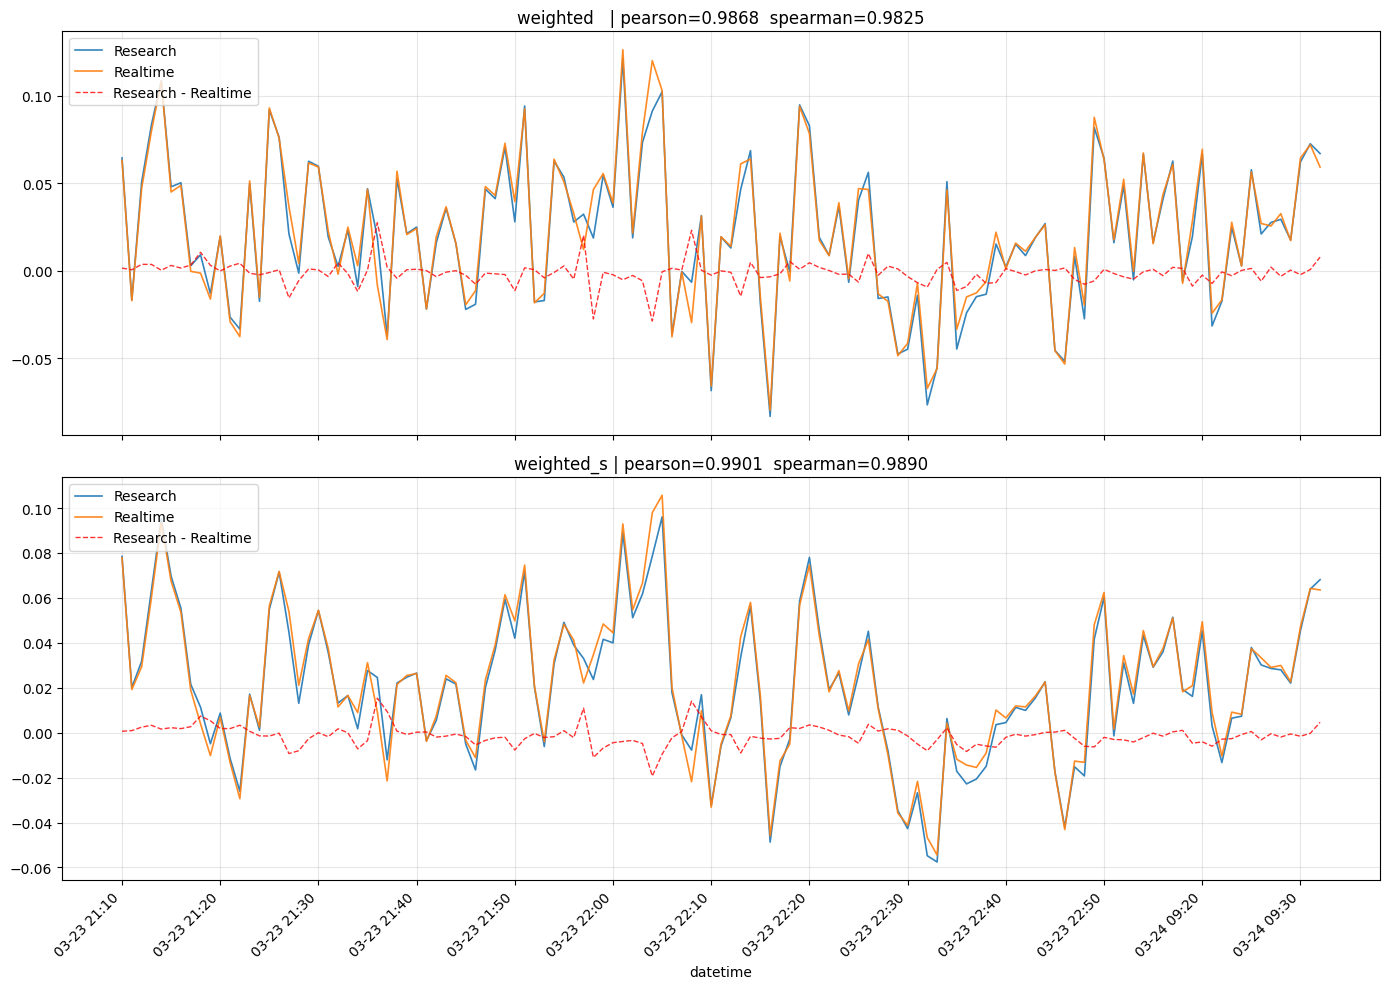


weighted   max_diff=0.028823  mean_diff=0.004155
weighted_s max_diff=0.019311  mean_diff=0.003310


In [17]:
from scipy import stats

# ---------- 交易时段过滤 ----------
idx = pred_res.index
mask = (
    ((idx.hour == 9) & (idx.minute >= 11)) |
    ((idx.hour >= 10) & (idx.hour <= 14)) |
    ((idx.hour == 15) & (idx.minute == 0)) |
    ((idx.hour == 21) & (idx.minute >= 10)) |
    ((idx.hour == 22) & (idx.minute <= 50))
)

pred_res_trade = pred_res.loc[mask]
rt_pred_trade  = rt_pred.loc[mask]

# ---------- 按天计算相关系数 ----------
corr_records = []
for td in sorted(set(pred_res_trade.index.date)):
    rs_day = pred_res_trade[pred_res_trade.index.date == td]
    rt_day = rt_pred_trade[rt_pred_trade.index.date == td]
    if len(rs_day) < 2:
        continue
    corr_records.append({
        'date': td,
        'w_pearson':  np.corrcoef(rs_day['weighted'],   rt_day['weighted'])[0,1],
        'w_spearman': stats.spearmanr(rs_day['weighted'],   rt_day['weighted'])[0],
        'ws_pearson': np.corrcoef(rs_day['weighted_s'].dropna(), rt_day['weighted_s'].dropna())[0,1],
        'ws_spearman': stats.spearmanr(rs_day['weighted_s'].dropna(), rt_day['weighted_s'].dropna())[0],
    })
corr_df = pd.DataFrame(corr_records)
print(corr_df.round(4))

# ---------- 整体相关系数 ----------
w_pearson  = np.corrcoef(pred_res_trade['weighted'],   rt_pred_trade['weighted'])[0,1]
w_spearman = stats.spearmanr(pred_res_trade['weighted'],   rt_pred_trade['weighted'])[0]
ws_pearson  = np.corrcoef(pred_res_trade['weighted_s'].dropna(), rt_pred_trade['weighted_s'].dropna())[0,1]
ws_spearman = stats.spearmanr(pred_res_trade['weighted_s'].dropna(), rt_pred_trade['weighted_s'].dropna())[0]

print(f"\nOverall | weighted   pearson={w_pearson:.4f} spearman={w_spearman:.4f}")
print(f"Overall | weighted_s pearson={ws_pearson:.4f} spearman={ws_spearman:.4f}")

# ---------- 画图：两张子图，x 轴等距序号 ----------
x_idx = np.arange(mask.sum())
x_labels = pred_res.loc[mask].index.strftime('%m-%d %H:%M')

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# weighted
axes[0].plot(x_idx, pred_res_trade['weighted'].values, label='Research', alpha=0.9, linewidth=1.2)
axes[0].plot(x_idx, rt_pred_trade['weighted'].values,  label='Realtime', alpha=0.9, linewidth=1.2)
axes[0].plot(x_idx, (pred_res_trade['weighted'].values - rt_pred_trade['weighted'].values),
             label='Research - Realtime', color='red', linestyle='--', alpha=0.8, linewidth=1.0)
axes[0].set_title(f'weighted   | pearson={w_pearson:.4f}  spearman={w_spearman:.4f}')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# weighted_s
axes[1].plot(x_idx, pred_res_trade['weighted_s'].values, label='Research', alpha=0.9, linewidth=1.2)
axes[1].plot(x_idx, rt_pred_trade['weighted_s'].values,  label='Realtime', alpha=0.9, linewidth=1.2)
axes[1].plot(x_idx, (pred_res_trade['weighted_s'].values - rt_pred_trade['weighted_s'].values),
             label='Research - Realtime', color='red', linestyle='--', alpha=0.8, linewidth=1.0)
axes[1].set_title(f'weighted_s | pearson={ws_pearson:.4f}  spearman={ws_spearman:.4f}')
axes[1].legend(loc='upper left')
axes[1].set_xlabel('datetime')
axes[1].grid(True, alpha=0.3)

step = max(1, len(x_idx) // 12)
axes[1].set_xticks(x_idx[::step])
axes[1].set_xticklabels(x_labels[::step], rotation=45, ha='right')

plt.tight_layout()
plt.show()

diff_w  = (pred_res_trade['weighted']   - rt_pred_trade['weighted']).abs()
diff_ws = (pred_res_trade['weighted_s'] - rt_pred_trade['weighted_s']).abs()
print(f"\nweighted   max_diff={diff_w.max():.6f}  mean_diff={diff_w.mean():.6f}")
print(f"weighted_s max_diff={diff_ws.max():.6f}  mean_diff={diff_ws.mean():.6f}")
